Nodes per layer:
  E: 11 nodes, mean influence 0.1784
  0: 833 nodes, mean influence 0.7207
  1: 509 nodes, mean influence 0.8071
  2: 357 nodes, mean influence 0.7826
  3: 383 nodes, mean influence 0.7947
  4: 551 nodes, mean influence 0.822
  5: 531 nodes, mean influence 0.8563
  6: 508 nodes, mean influence 0.8479
  7: 327 nodes, mean influence 0.8452
  8: 249 nodes, mean influence 0.8316
  9: 287 nodes, mean influence 0.8472
  10: 278 nodes, mean influence 0.8756
  11: 51 nodes, mean influence 0.7879
  12: 43 nodes, mean influence 0.76
  13: 55 nodes, mean influence 0.8048
  14: 51 nodes, mean influence 0.7757
  15: 44 nodes, mean influence 0.7572
  16: 37 nodes, mean influence 0.718
  17: 41 nodes, mean influence 0.7352
  18: 40 nodes, mean influence 0.7224
  19: 25 nodes, mean influence 0.7039
  20: 32 nodes, mean influence 0.6788
  21: 29 nodes, mean influence 0.7196
  22: 18 nodes, mean influence 0.636
  23: 27 nodes, mean influence 0.6068
  24: 24 nodes, mean influence 0.5956


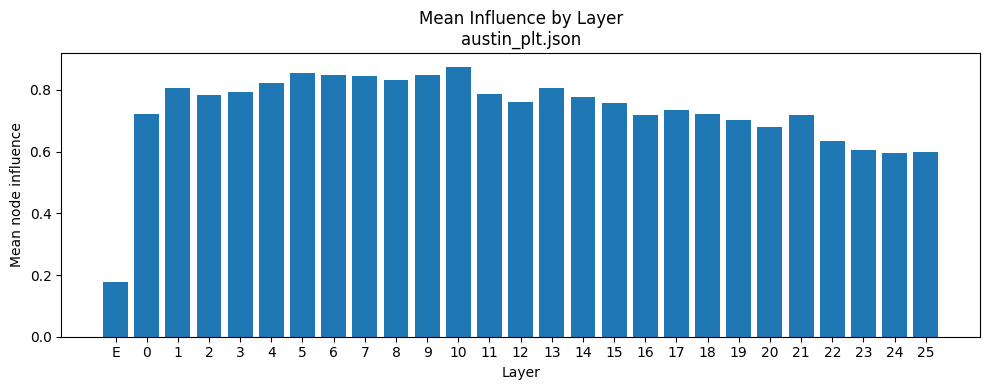

{'0': 0.7206691480985209,
 '1': 0.8070795473391977,
 '2': 0.7825524525649074,
 '3': 0.7946935101526524,
 '4': 0.8220003495523588,
 '5': 0.8562901596452781,
 '6': 0.8479303788599066,
 '7': 0.8452386786813765,
 '8': 0.8316483419822401,
 '9': 0.8472122112840725,
 '10': 0.8756172156376805,
 '11': 0.7878806795559677,
 '12': 0.7599536492380985,
 '13': 0.8047857831824909,
 '14': 0.7756590673736498,
 '15': 0.7571992704814131,
 '16': 0.7179797613942945,
 '17': 0.7351786726858558,
 '18': 0.7223523303866386,
 '19': 0.7039155161380768,
 '20': 0.6788460677489638,
 '21': 0.7195629241137669,
 '22': 0.6359769056240717,
 '23': 0.6068333519829644,
 '24': 0.5956492361923059,
 '25': 0.597991495363174,
 'E': 0.17840622941201384}

In [2]:
import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def plot_mean_influence_by_layer(graph_json_path: str):
    p = Path(graph_json_path)
    with p.open("r", encoding="utf-8") as f:
        data = json.load(f)

    nodes = data.get("nodes", [])
    layer_to_vals = defaultdict(list)
    layer_counts = defaultdict(int)

    for n in nodes:
        layer = str(n.get("layer", "unknown"))
        layer_counts[layer] += 1
        influence = n.get("influence", None)
        if isinstance(influence, (int, float)) and np.isfinite(influence):
            layer_to_vals[layer].append(float(influence))

    # keep layers with at least 1 valid influence
    layer_mean = {
        layer: float(np.mean(vals))
        for layer, vals in layer_to_vals.items()
        if len(vals) > 0
    }

    # sort: E first, then numeric layers, then anything else
    def layer_key(x: str):
        if x == "E":
            return (0, -1)
        if x.isdigit():
            return (1, int(x))
        return (2, x)

    # print counts per layer (include layers without valid influence)
    all_layers = sorted(set(list(layer_counts.keys()) | set(layer_mean.keys())), key=layer_key)
    print("Nodes per layer:")
    for l in all_layers:
        cnt = layer_counts.get(l, 0)
        if l in layer_mean:
            print(f"  {l}: {cnt} nodes, mean influence {layer_mean[l]:.4g}")
        else:
            print(f"  {l}: {cnt} nodes, no valid influence")

    layers = sorted(layer_mean.keys(), key=layer_key)
    means = [layer_mean[l] for l in layers]

    plt.figure(figsize=(10, 4))
    plt.bar(layers, means)
    plt.xlabel("Layer")
    plt.ylabel("Mean node influence")
    plt.title(f"Mean Influence by Layer\n{p.name}")
    plt.tight_layout()
    plt.show()
    
    return layer_mean


# Example:
plot_mean_influence_by_layer("temp_graph_files/austin_plt.json")

In [16]:
from circuit_tracer.subgraph.utils import get_data_from_json, _build_index_sets
from circuit_tracer.graph import compute_node_influence, compute_node_relevance
import torch
adj_matrix, node_ids, attr, metadata = get_data_from_json("temp_graph_files/austin_plt.json")

idx = _build_index_sets(node_ids, attr)
n = adj_matrix.shape[0]
logits_seed = torch.zeros(n, device=adj_matrix.device)
for i in idx["logit"]:
    nid = node_ids[i]
    logits_seed[i] = float(attr.get(nid, {}).get("token_prob", 0.0))
influence = compute_node_influence(adj_matrix, logits_seed)

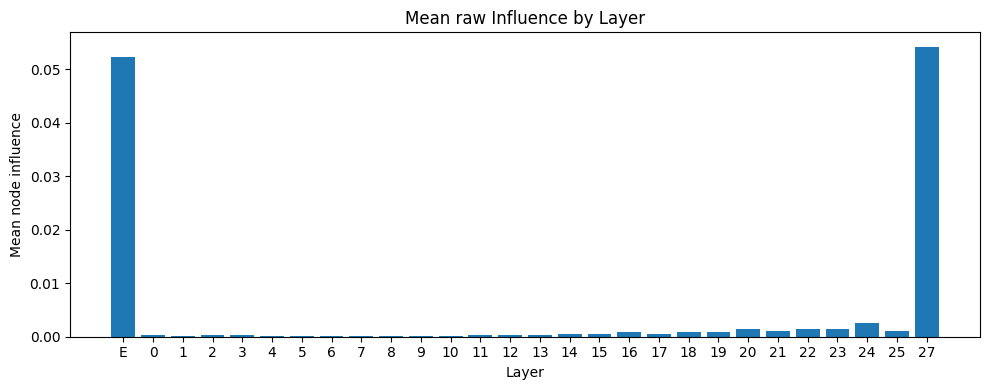

In [17]:
from collections import defaultdict

mean_inf_by_layer = defaultdict(list)
for i, inf in enumerate(influence):
    layer = attr.get(node_ids[i], {}).get("layer", "unknown")
    try:
        val = float(inf)
    except Exception:
        continue
    if np.isfinite(val):
        mean_inf_by_layer[str(layer)].append(val)

layer_mean = {layer: float(np.mean(vals)) for layer, vals in mean_inf_by_layer.items() if len(vals) > 0}

def layer_key(x: str):
    if x == "E":
        return (0, -1)
    if x.isdigit():
        return (1, int(x))
    return (2, x)

layers = sorted(layer_mean.keys(), key=layer_key)
means = [layer_mean[l] for l in layers]

plt.figure(figsize=(10, 4))
plt.bar(layers, means)
plt.xlabel("Layer")
plt.ylabel("Mean node influence")
plt.title("Mean raw Influence by Layer")
plt.tight_layout()
plt.show()


In [18]:
print(means)

[0.05219008502635089, 0.0004026351485580148, 0.0002227898450962964, 0.00028666587810963066, 0.00024408796864778154, 0.00022289976935270175, 0.00015271380480540883, 0.0001686459789011929, 0.0001929179247155777, 0.00019627036202741493, 0.0001722329984928517, 0.00013892804060737258, 0.0003302108191693311, 0.0003795868891080148, 0.0003544836798524061, 0.00047966764495689787, 0.00048585950034149306, 0.0008079745531250484, 0.0004865350965701509, 0.0008126214141157106, 0.0009161317709367723, 0.0014710239383930457, 0.0011599440693881378, 0.0014616006547940844, 0.0015271886850651182, 0.002552390446605083, 0.0010666150523203186, 0.054160252368698515]
